In [148]:
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import polars as pl
import colorir as cl
import numpy as np
from analyses.parse import parse_cells_multiple

In [2]:
sim_paths = {}
for path in Path("../runs/speed/").iterdir():
    sim_type = path.name
    gamma = 20 - int(sim_type.split("-")[1])
    for replica_path in path.iterdir():
        replica = int(replica_path.name)
        sim_paths[(gamma, replica)] = replica_path

In [3]:
sims = parse_cells_multiple(sim_paths.values(), 30)

In [32]:
sim_ids = list(sim_paths.keys())
for i in range(len(sims)):
    sims[i] = sims[i].with_columns(
        gamma=sim_ids[i][0], 
        sim_replica=sim_ids[i][1]
    )
celldf = pl.concat(sims)
celldf = celldf.with_columns(
    displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5
)

In [5]:
grouppers = ["gamma", "sim_replica", "time"]
displdf = celldf.group_by(grouppers).agg(
    cluster_x=pl.col("center_x").mean(),
    cluster_y=pl.col("center_y").mean(),
    mean_displ=pl.col("displ").mean(),
    med_displ=pl.col("displ").median()
).sort(grouppers)
displdf

gamma,sim_replica,time,cluster_x,cluster_y,mean_displ,med_displ
i32,i32,i32,f32,f32,f32,f32
0,0,0,433.300049,433.299988,614.067871,615.056519
0,0,100000,374.361847,362.397461,530.212097,546.781738
0,0,200000,318.912354,323.1073,474.199799,478.11142
0,0,300000,287.697052,289.229279,430.144165,467.157349
0,0,400000,280.46048,275.529236,425.530945,445.333221
…,…,…,…,…,…,…
20,4,14500000,77.122459,74.833153,116.028175,122.764511
20,4,14600000,82.664749,79.359482,121.106537,124.670845
20,4,14700000,89.211922,73.46209,122.026901,123.379669


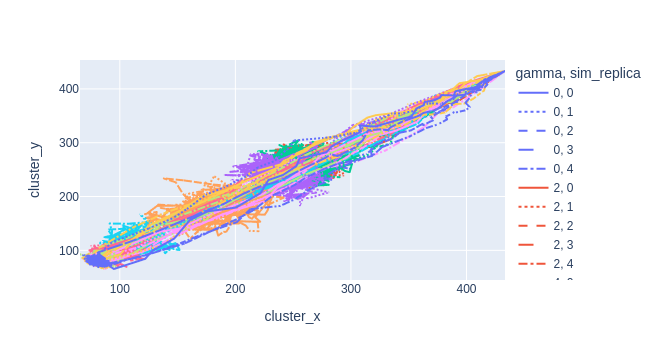

In [6]:
# Cluster trajectories
px.line(
    displdf,
    x="cluster_x",
    y="cluster_y",
    color="gamma",
    line_dash="sim_replica"
)

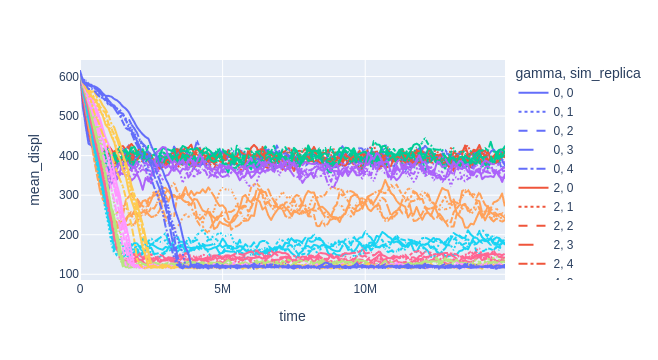

In [7]:
px.line(
    displdf,
    x="time",
    y="mean_displ",
    color="gamma",
    line_dash="sim_replica"
)

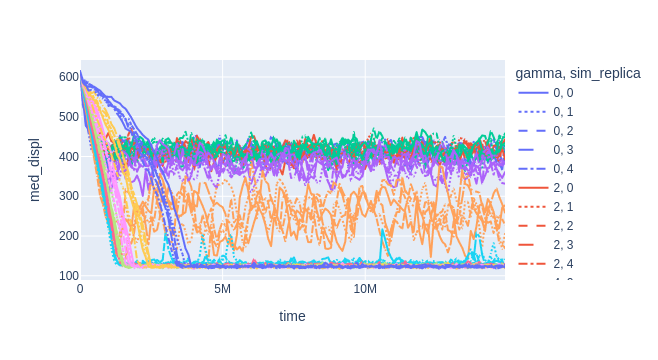

In [8]:
px.line(
    displdf,
    x="time",
    y="med_displ",
    color="gamma",
    line_dash="sim_replica"
)

In [9]:
repldf = displdf.group_by(["gamma", "time"]).agg(
    med_med=pl.col("med_displ").median(),
    med_mean=pl.col("med_displ").mean(),
    med_min=pl.col("med_displ").min(),
    med_max=pl.col("med_displ").max(),
    mean_mean=pl.col("mean_displ").mean(),
    mean_med=pl.col("mean_displ").median(),
    mean_min=pl.col("mean_displ").min(),
    mean_max=pl.col("mean_displ").max(),
).sort(["gamma", "time"])
repldf

gamma,time,med_med,med_mean,med_min,med_max,mean_mean,mean_med,mean_min,mean_max
i32,i32,f32,f32,f32,f32,f32,f32,f32,f32
0,0,615.056519,615.056519,615.056519,615.056519,614.067871,614.067871,614.067871,614.067993
0,100000,536.782532,537.724731,528.370239,546.781738,528.337341,530.212097,521.556396,534.718506
0,200000,498.899963,493.850891,478.11142,500.450867,481.424316,482.607727,474.199799,488.611176
0,300000,467.157349,465.389404,458.508728,473.991516,442.056885,443.143951,430.144165,451.102112
0,400000,445.123291,439.624664,416.558777,447.097595,427.604736,428.804565,422.975983,430.508698
…,…,…,…,…,…,…,…,…,…
20,14500000,122.293686,122.003311,120.38105,123.304123,117.562767,118.326614,115.148811,119.221054
20,14600000,124.670845,122.635887,117.901688,125.459671,119.133034,120.730263,114.031639,122.338379
20,14700000,120.881912,121.953514,119.597107,126.012596,118.925034,117.912323,116.242958,122.15612


/tmp/ipykernel_380420/3328495102.py:3: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



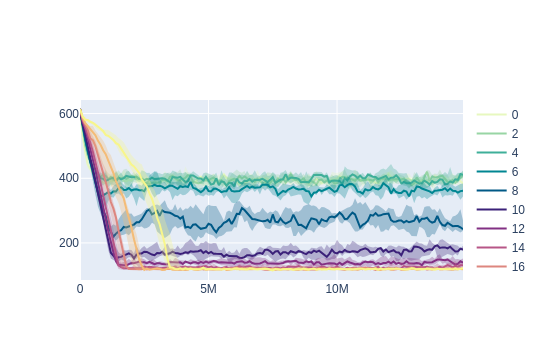

In [105]:
import random as rand

palette = cl.Grad(cl.StackPalette.load("carnival"), domain=[0, 20])
fig = go.Figure()
for gamma, group in repldf.group_by("gamma"):
    gamma = gamma[0]
    fig.add_trace(go.Scatter(
        x=group["time"],
        y=group["mean_med"],
        line_color=palette(gamma),
        name=gamma
    ))
    fig.add_trace(go.Scatter(
        x=pl.concat([group["time"], group["time"][::-1]]),
        y=pl.concat([group["mean_min"], group["mean_max"][::-1]]),
        fill="toself",
        line_color="rgba(0, 0, 0, 0)",
        fillcolor=palette(gamma),
        opacity=0.3,
        showlegend=False
    ))
fig

In [11]:
concdf = displdf.filter(pl.col("time") > 10e6).group_by(["gamma"]).agg(
    med=pl.col("mean_displ").median(),
    min=pl.col("mean_displ").min(),
    max=pl.col("mean_displ").max(),
)
concdf

gamma,med,min,max
i32,f32,f32,f32
0,394.49118,360.31073,428.470856
2,396.237885,361.216217,427.734467
4,396.484467,354.667816,444.372894
6,364.045074,322.777588,407.120911
8,269.016846,217.816711,338.347137
…,…,…,…
12,139.383881,124.153564,165.040268
14,123.359787,114.844238,144.442886
16,119.1334,113.931862,129.960297


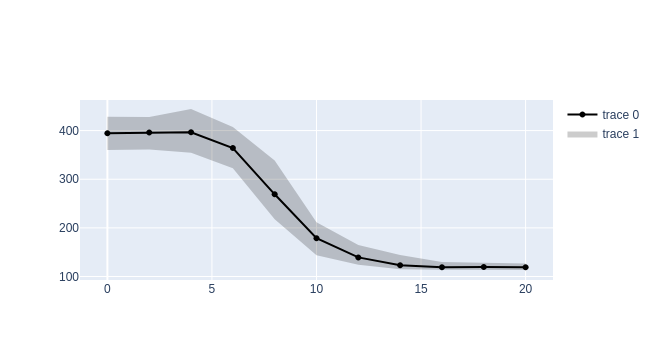

In [12]:
fig = go.Figure([
    go.Scatter(
        x=concdf["gamma"],
        y=concdf["med"],
        line_color="black"
    ),
    go.Scatter(
        x=pl.concat([concdf["gamma"], concdf["gamma"][::-1]]),
        y=pl.concat([concdf["min"], concdf["max"][::-1]]),
        fill="toself",
        line_color="rgba(0, 0, 0, 0)",
        fillcolor="rgba(0, 0, 0, 0.2)"
    )
])
fig

In [130]:
filterdf = celldf\
    .join(displdf, on=["gamma", "sim_replica", "time"])\
    .group_by("gamma")\
    .agg(
        pl.col("*").filter(
            pl.col("time") > 0.25e6,
            pl.col("time") < pl.col("time").filter(pl.col("mean_displ") <= pl.col("mean_displ").filter(pl.col("time") > 1e7).mean()).min()
        )
    )\
    .explode(pl.exclude("gamma"))\
    .sort(["gamma", "sim_replica", "time"])
filterdf

gamma,index,ancestor,area,target_area,perimeter,target_perimeter,center_x,center_y,chem_center_x,chem_center_y,chem_mass,ligands,receptors,time,sim_replica,displ,cluster_x,cluster_y,mean_displ,med_displ
i32,u32,u32,u32,u32,u32,u32,f32,f32,f32,f32,u32,u64,u64,i32,i32,f32,f32,f32,f32,f32
0,49,49,200,200,188,180,62.549995,219.6884,62.574402,219.653961,95906,4,135,300000,0,228.419556,287.697052,289.229279,430.144165,467.157349
0,60,60,200,200,184,180,272.127777,79.726913,272.079529,79.697678,84881,38,198,300000,0,283.566406,287.697052,289.229279,430.144165,467.157349
0,3,3,199,200,180,180,231.038742,101.763626,230.959167,101.746597,90652,173,255,300000,0,252.457397,287.697052,289.229279,430.144165,467.157349
0,2,2,200,200,178,180,176.760239,330.233276,176.720901,330.183167,66686,59,26,300000,0,374.564026,287.697052,289.229279,430.144165,467.157349
0,1,1,200,200,180,180,291.030426,93.899796,291.03064,93.898453,80424,187,197,300000,0,305.80368,287.697052,289.229279,430.144165,467.157349
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20,5,5,200,200,182,180,98.349213,145.60463,98.29155,145.584015,106455,34,184,3400000,4,175.707932,91.643089,71.863228,123.529892,125.507339
20,4,4,200,200,190,180,79.231354,82.892555,79.209518,82.896088,118635,60,213,3400000,4,114.668144,91.643089,71.863228,123.529892,125.507339
20,3,3,200,200,186,180,73.884331,55.195061,73.860397,55.202133,123138,19,247,3400000,4,92.224663,91.643089,71.863228,123.529892,125.507339


In [124]:
def circmean(expr):
    return pl.arctan2(expr.sin().sum(), expr.cos().sum())


cellveldf = filterdf\
    .sort("time")\
    .group_by(["gamma", "sim_replica", "index"])\
    .agg(
        vel=pl.col("displ").diff().abs().mean(),
        arc=circmean(pl.arctan2(
            pl.col("center_y").diff(), 
            pl.col("center_x").diff()
        ))
)
cellveldf

gamma,sim_replica,index,vel,arc
i32,i32,u32,f32,f32
14,1,26,43.479675,-2.367716
0,2,80,37.317322,-1.988778
6,4,26,43.670593,-2.191109
12,2,13,39.175453,-2.406003
4,2,79,42.377197,2.738859
…,…,…,…,…
14,2,66,29.798586,-2.150754
16,2,14,29.520313,-2.475621
0,4,30,151.380096,1.440117


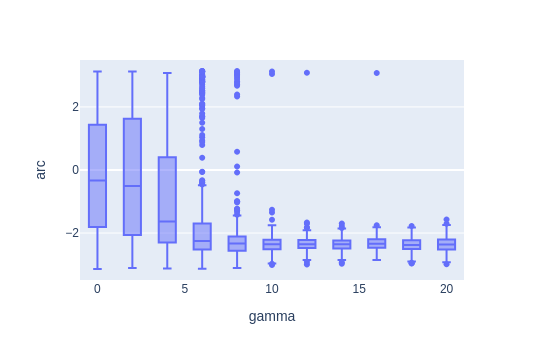

In [276]:
px.box(cellveldf, x="gamma", y="arc").update_layout(width=600)

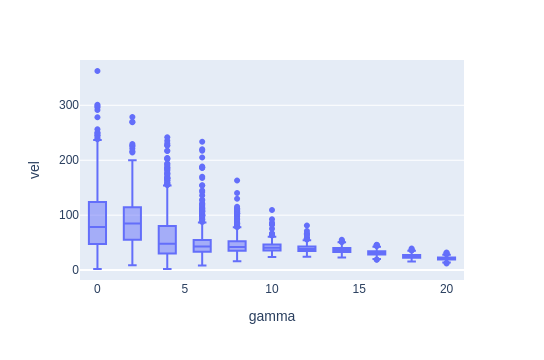

In [126]:
px.box(cellveldf, x="gamma", y="vel").update_layout(width=600)

In [370]:
angles = pl.arctan2(
    pl.col("cluster_y").diff(),
    pl.col("cluster_x").diff()
) - pl.arctan2(
    -pl.col("cluster_y"),
    -pl.col("cluster_x")
)
angles_wrapped = (angles + np.pi) % (2 * np.pi) - np.pi

clusterveldf = filterdf\
    .group_by(["gamma", "sim_replica", "time"])\
    .agg(
        pl.col("mean_displ").first(),
        pl.col("cluster_x").first(),
        pl.col("cluster_y").first()
    )\
    .sort("time")\
    .group_by(["gamma", "sim_replica"])\
    .agg(
        vel=pl.col("mean_displ")\
            .diff()\
            .abs()\
            .mean(),
        arc=circmean(pl.arctan2(
            pl.col("cluster_y").diff(), 
            pl.col("cluster_x").diff()
        )),
        align=(angles_wrapped.cos().mean() ** 2 + angles_wrapped.sin().mean() ** 2).sqrt()
    )
clusterveldf

gamma,sim_replica,vel,arc,align
i32,i32,f32,f32,f32
14,3,33.737499,-2.373616,0.968517
0,1,16.007034,-1.539903,0.997194
16,1,26.514805,-2.376261,0.949808
14,4,35.743896,-2.374725,0.988271
4,3,24.255325,-2.20134,0.967824
…,…,…,…,…
12,0,34.743233,-2.358364,0.987337
20,1,12.541409,-2.4536,0.92963
20,4,14.576419,-2.302911,0.830841


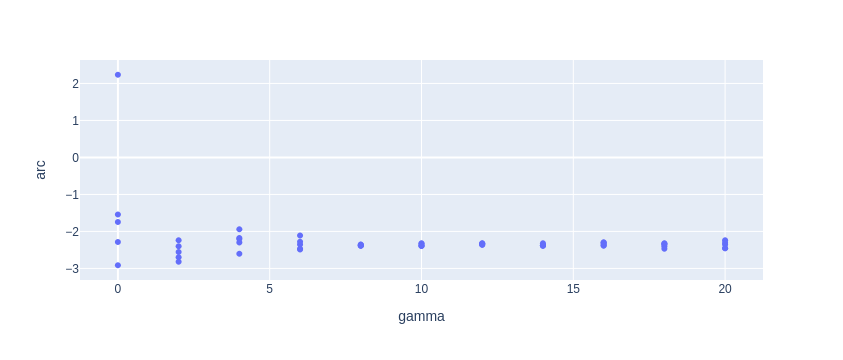

In [372]:
px.scatter(clusterveldf, x="gamma", y="arc").update_layout(width=600)

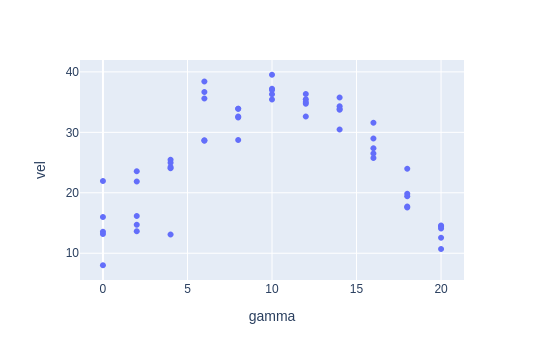

In [343]:
px.scatter(clusterveldf, x="gamma", y="vel").update_layout(width=600)

In [344]:
veldf = cellveldf.join(
    clusterveldf, 
    ["gamma", "sim_replica"],
    suffix="_cluster"
).group_by("gamma").agg(
    mean_vel=pl.col("vel").mean(),
    mean_vel_cluster=pl.col("vel_cluster").mean()
)
veldf

gamma,mean_vel,mean_vel_cluster
i32,f32,f32
14,36.608063,33.63522
10,42.014515,37.084778
8,47.254845,32.330254
12,39.254448,34.842014
0,90.561417,14.545332
…,…,…
20,21.237017,13.261695
18,25.117126,19.721043
16,31.429441,28.04129


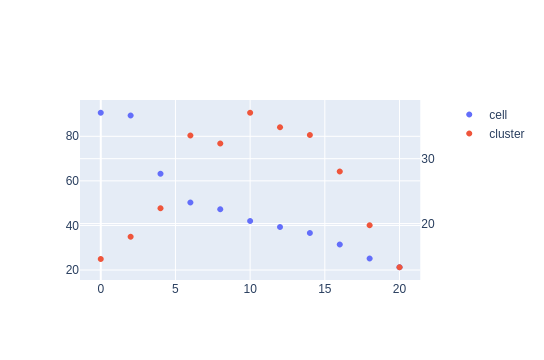

In [345]:
# Non-linear relationship between cell speed and cluster speed
# Or it is linear but strength of CIL depends on gamma? 
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(
    x=veldf["gamma"],
    y=veldf["mean_vel"],
    mode="markers",
    name="cell"
))
fig.add_trace(go.Scatter(
    x=veldf["gamma"],
    y=veldf["mean_vel_cluster"],
    mode="markers",
    name="cluster"
), secondary_y=True)

In [425]:
displ_cuts = np.linspace(0, (2 * 500 ** 2) ** 0.5, 8)
time_cuts = np.arange(0, celldf["time"].max() + 2e6, 2e6)

angles = pl.arctan2(
    pl.col("center_y").diff(),
    pl.col("center_x").diff()
) - pl.arctan2(
    -pl.col("center_y"),
    -pl.col("center_x")
)
angles_wrapped = (angles + np.pi) % (2 * np.pi) - np.pi

arcdf = celldf\
    .filter(pl.col("time") > 1e7)\
    .with_columns(
        q_displ=pl.col("displ")\
            .cut(
                displ_cuts[1:],
                labels=displ_cuts.astype(str)
            )\
            .cast(str)
            .cast(pl.Float64),
        q_time=pl.col("time")\
            .cut(
                time_cuts[1:],
                labels=time_cuts.astype(str)
            )\
            .cast(str)
            .cast(pl.Float64)
    )\
    .sort("time")\
    .group_by(["gamma", "sim_replica", "index", "q_time"])\
    .agg(
        n_times=pl.col("time").n_unique(),
        arc=circmean(pl.arctan2(
            pl.col("center_y").diff(), 
            pl.col("center_x").diff()
        )),
        align=(angles_wrapped.cos().mean() ** 2 + angles_wrapped.sin().mean() ** 2).sqrt()
    )\
    .sort(["gamma", "sim_replica", "index", "q_time"])
arcdf

gamma,sim_replica,index,q_time,n_times,arc,align
i32,i32,u32,f64,u32,f32,f32
0,0,0,1e7,20,-2.421826,0.090938
0,0,0,1.2e7,20,-0.133776,0.183048
0,0,0,1.4e7,9,-0.787795,0.222696
0,0,1,1e7,20,-1.50954,0.101765
0,0,1,1.2e7,20,-0.488013,0.318979
…,…,…,…,…,…,…
20,4,98,1.2e7,20,0.778094,0.222002
20,4,98,1.4e7,9,-0.968979,0.268137
20,4,99,1e7,20,-1.6959,0.151289


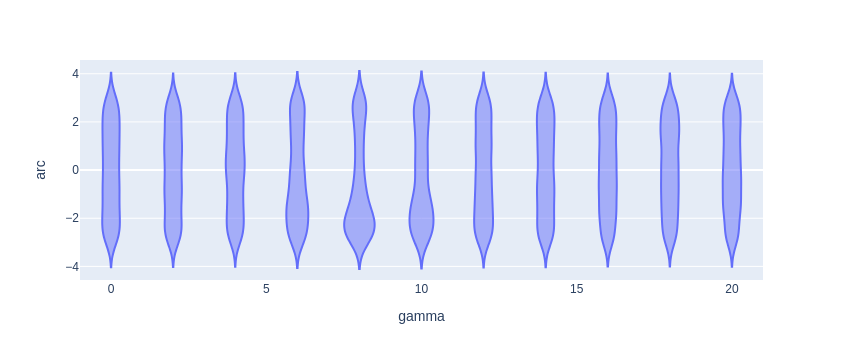

In [426]:
px.violin(
    arcdf,
    x="gamma",
    y="arc",
    width=1200
)